In [10]:
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd
import csv
import numpy as np

In [11]:
cam_data = pd.read_csv("cam4_processed.csv")
joint_data = pd.read_csv("joint_log.csv")

# Keep only monotonic_ns and q5 from joint log and compute abs joint_ang relative to first q5
joint_data = joint_data[["monotonic_ns", "q5"]].copy()
joint_data["q5"] = pd.to_numeric(joint_data["q5"], errors="coerce")
joint_zero = joint_data["q5"].iloc[0]
joint_data["joint_ang"] = -(joint_data["q5"] - joint_zero) * 180.0 / np.pi

# Compute cam_ang from unit vectors x/y relative to first row angle, then use abs and cap over 90 by subtracting 90
cam_data = cam_data.copy()
cam_data["vector_x"] = pd.to_numeric(cam_data["vector_x"], errors="coerce")
cam_data["vector_y"] = pd.to_numeric(cam_data["vector_y"], errors="coerce")
first_cam_angle = np.arctan2(cam_data.loc[0, "vector_y"], cam_data.loc[0, "vector_x"])
cam_data["cam_ang"] = np.degrees(np.arctan2(cam_data["vector_y"], cam_data["vector_x"]) - first_cam_angle)
cam_data["cam_ang"] = ((cam_data["cam_ang"] + 180) % 360) - 180
# cam_data["cam_ang"] = np.abs(cam_data["cam_ang"])
# cam_data.loc[cam_data["cam_ang"] > 90, "cam_ang"] = 180 - cam_data.loc[cam_data["cam_ang"] > 90, "cam_ang"]

# Merge on monotonic_ns, keep both sides, sort and backfill missing values
merged = pd.merge(cam_data, joint_data, on="monotonic_ns", how="outer", suffixes=("_cam", "_joint"))
merged = merged.sort_values("monotonic_ns").reset_index(drop=True)
merged = merged.bfill()
merged = merged[["monotonic_ns", "captured_time_ns", "cam_ang", "joint_ang"]]

# Restrict to the region of interest
merged = merged[(merged["monotonic_ns"] > 24253284416022) & (merged["monotonic_ns"] < 24275868433837)].reset_index(drop=True)

merged.head()


,monotonic_ns,captured_time_ns,cam_ang,joint_ang
0,24253285101407,2.425342e+13,-1.880363,-1.003879
1,24253286403513,2.425344e+13,-1.996107,-1.003879
2,24253288422812,2.425344e+13,-1.996107,-1.022386
3,24253290406520,2.425344e+13,-1.996107,-1.043012
4,24253292413895,2.425344e+13,-1.996107,-1.062264


In [12]:
merged.to_csv("merged_output.csv", index=False)
print("Exported merged_output.csv")

Exported merged_output.csv


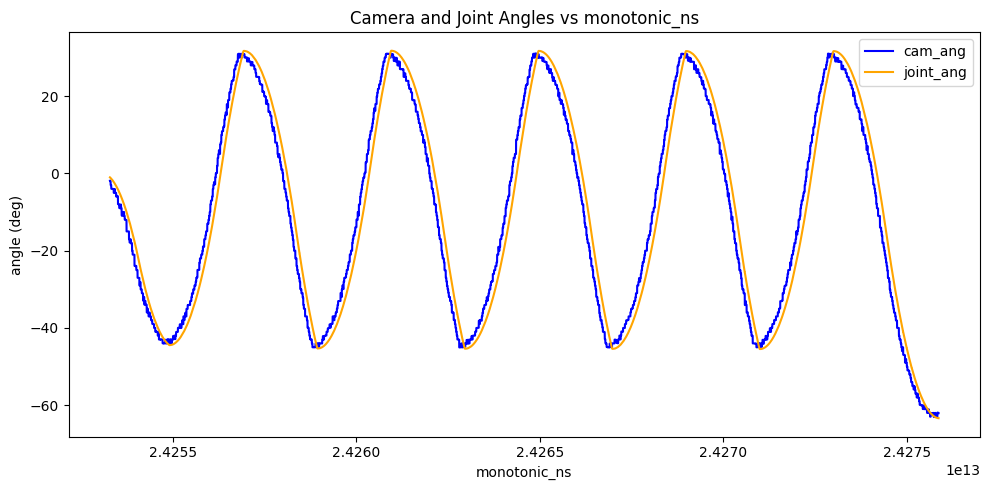

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(merged["monotonic_ns"], merged["cam_ang"], label="cam_ang", color="blue")
plt.plot(merged["monotonic_ns"], merged["joint_ang"], label="joint_ang", color="orange")
plt.xlabel("monotonic_ns")
plt.ylabel("angle (deg)")
plt.legend()
plt.title("Camera and Joint Angles vs monotonic_ns")
plt.tight_layout()
plt.show()

Estimated phase shift: -48 samples
Estimated phase shift: -95439984 ns (-0.095440 s)
Positive lag means cam_ang leads joint_ang. Negative lag means cam_ang lags joint_ang.


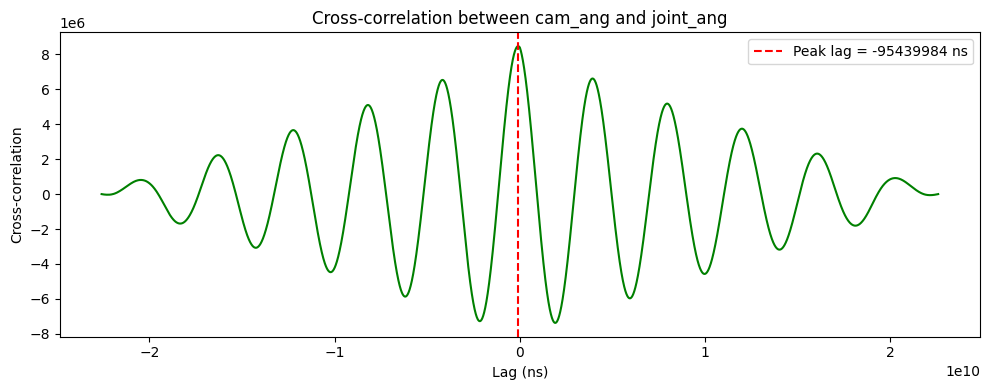

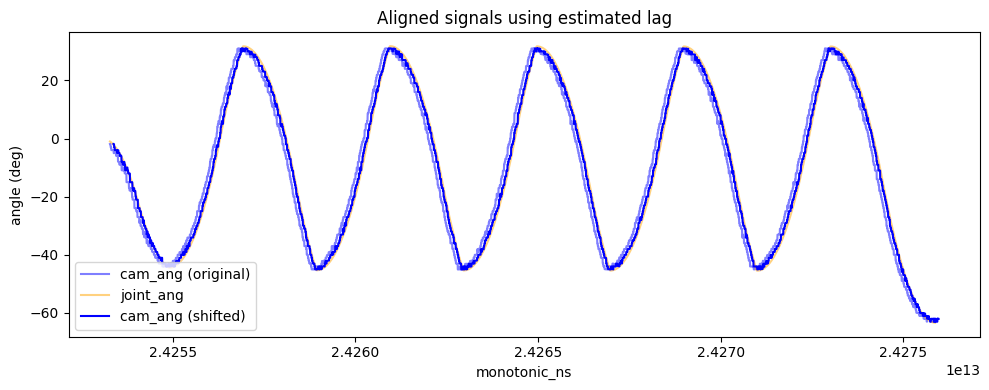

In [14]:
# Measure phase shift between cam_ang and joint_ang in monotonic_ns using cross-correlation.
clean = merged[['monotonic_ns', 'cam_ang', 'joint_ang']].dropna()
if len(clean) < 5:
    raise ValueError('Not enough matched data points to compute phase shift.')

times = clean['monotonic_ns'].to_numpy(dtype=np.float64)
cam = clean['cam_ang'].to_numpy(dtype=np.float64)
joint = clean['joint_ang'].to_numpy(dtype=np.float64)

# Resample to uniform time spacing for cross-correlation.
dt = np.median(np.diff(times))
uniform_times = np.arange(times[0], times[-1] + dt, dt)
cam_resampled = np.interp(uniform_times, times, cam)
joint_resampled = np.interp(uniform_times, times, joint)

cam_d = cam_resampled - np.mean(cam_resampled)
joint_d = joint_resampled - np.mean(joint_resampled)
correlation = np.correlate(cam_d, joint_d, mode='full')
lag_index = np.argmax(correlation) - (len(cam_d) - 1)
lag_ns = lag_index * dt
lag_sec = lag_ns * 1e-9

print(f'Estimated phase shift: {lag_index} samples')
print(f'Estimated phase shift: {lag_ns:.0f} ns ({lag_sec:.6f} s)')
print('Positive lag means cam_ang leads joint_ang. Negative lag means cam_ang lags joint_ang.')

# Visualize the cross-correlation and aligned signals.
plt.figure(figsize=(10, 4))
lag_times = np.arange(-len(cam_d) + 1, len(cam_d)) * dt
plt.plot(lag_times, correlation, color='green')
plt.axvline(lag_ns, color='red', linestyle='--', label=f'Peak lag = {lag_ns:.0f} ns')
plt.xlabel('Lag (ns)')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation between cam_ang and joint_ang')
plt.legend()
plt.tight_layout()
plt.show()

# Plot aligned signals after shifting cam_ang by the estimated lag.
shifted_times = uniform_times - lag_ns
plt.figure(figsize=(10, 4))
plt.plot(uniform_times, cam_resampled, label='cam_ang (original)', color='blue', alpha=0.5)
plt.plot(uniform_times, joint_resampled, label='joint_ang', color='orange', alpha=0.5)
plt.plot(shifted_times, cam_resampled, label='cam_ang (shifted)', color='blue')
plt.xlabel('monotonic_ns')
plt.ylabel('angle (deg)')
plt.title('Aligned signals using estimated lag')
plt.legend()
plt.tight_layout()
plt.show()

cam  derivative zero crossings: 67
joint derivative zero crossings: 10

Median lag per zero-crossing pair: 90346988 ns  (90.347 ms)
Positive  → joint lags cam  (cam leads)
Negative  → cam  lags joint (joint leads)


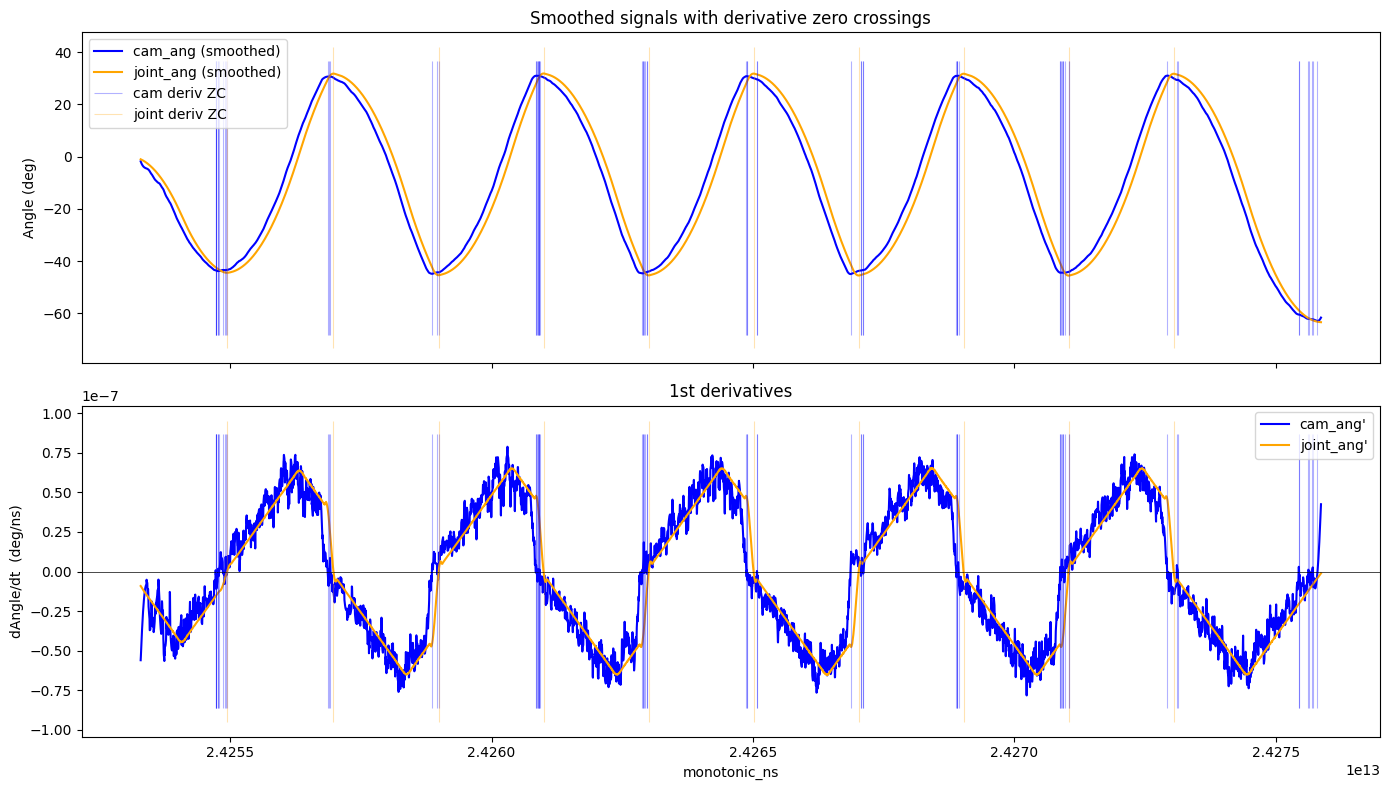

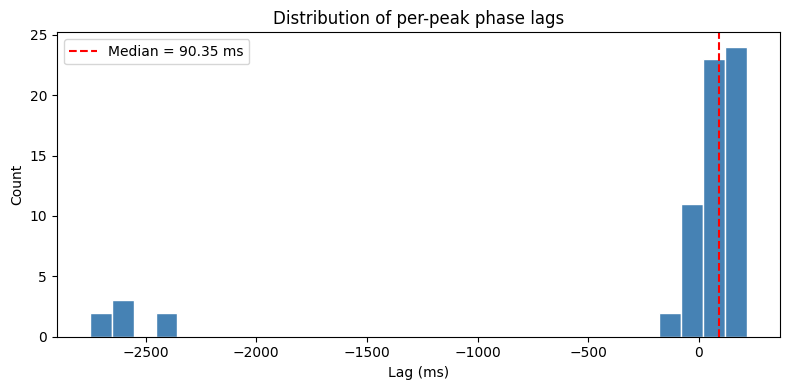

In [15]:

from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

# --- Resample to uniform time grid ---
clean = merged[['monotonic_ns', 'cam_ang', 'joint_ang']].dropna()
times = clean['monotonic_ns'].to_numpy(dtype=np.float64)
cam = clean['cam_ang'].to_numpy(dtype=np.float64)
joint = clean['joint_ang'].to_numpy(dtype=np.float64)

dt = np.median(np.diff(times))
uniform_times = np.arange(times[0], times[-1] + dt, dt)
cam_r = np.interp(uniform_times, times, cam)
joint_r = np.interp(uniform_times, times, joint)

# --- Smoothing (Savitzky-Golay) ---
# window_length must be odd; adjust as needed relative to signal frequency
win = max(11, int(len(uniform_times) * 0.01) | 1)   # ~1% of data, forced odd
poly = 3
cam_s = savgol_filter(cam_r, window_length=win, polyorder=poly)
joint_s = savgol_filter(joint_r, window_length=win, polyorder=poly)

# --- 1st-order derivative ---
cam_d1 = np.gradient(cam_s, dt)
joint_d1 = np.gradient(joint_s, dt)

# --- Zero crossings of the derivative (peaks/troughs of original signal) ---
def zero_crossing_times(signal, t):
    """Return times of sign changes (zero crossings) in signal."""
    signs = np.sign(signal)
    # ignore exact zeros - treat as previous sign
    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]
    cross_idx = np.where(np.diff(signs))[0]
    # Linear interpolation for sub-sample accuracy
    zc_times = []
    for idx in cross_idx:
        t0, t1 = t[idx], t[idx + 1]
        s0, s1 = signal[idx], signal[idx + 1]
        if s1 != s0:
            zc_times.append(t0 - s0 * (t1 - t0) / (s1 - s0))
    return np.array(zc_times)

cam_zc = zero_crossing_times(cam_d1, uniform_times)
joint_zc = zero_crossing_times(joint_d1, uniform_times)

print(f"cam  derivative zero crossings: {len(cam_zc)}")
print(f"joint derivative zero crossings: {len(joint_zc)}")

# --- Match each cam ZC to nearest joint ZC ---
lags = []
for t_cam in cam_zc:
    diffs = joint_zc - t_cam
    nearest = diffs[np.argmin(np.abs(diffs))]
    # Only accept matches within half a period (avoid false matches)
    lags.append(nearest)

lags = np.array(lags)
median_lag_ns = np.median(lags)
median_lag_s  = median_lag_ns * 1e-9

print(f"\nMedian lag per zero-crossing pair: {median_lag_ns:.0f} ns  ({median_lag_s*1000:.3f} ms)")
print("Positive  → joint lags cam  (cam leads)")
print("Negative  → cam  lags joint (joint leads)")

# --- Visualise smoothed signals, derivatives, and zero crossings ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(uniform_times, cam_s,   label='cam_ang (smoothed)',   color='blue')
axes[0].plot(uniform_times, joint_s, label='joint_ang (smoothed)', color='orange')
axes[0].vlines(cam_zc,   *axes[0].get_ylim(), color='blue',   alpha=0.3, linewidth=0.8, label='cam deriv ZC')
axes[0].vlines(joint_zc, *axes[0].get_ylim(), color='orange', alpha=0.3, linewidth=0.8, label='joint deriv ZC')
axes[0].set_ylabel('Angle (deg)')
axes[0].set_title('Smoothed signals with derivative zero crossings')
axes[0].legend()

axes[1].plot(uniform_times, cam_d1,   label="cam_ang'",   color='blue')
axes[1].plot(uniform_times, joint_d1, label="joint_ang'", color='orange')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].vlines(cam_zc,   axes[1].get_ylim()[0], axes[1].get_ylim()[1], color='blue',   alpha=0.3, linewidth=0.8)
axes[1].vlines(joint_zc, axes[1].get_ylim()[0], axes[1].get_ylim()[1], color='orange', alpha=0.3, linewidth=0.8)
axes[1].set_ylabel('dAngle/dt  (deg/ns)')
axes[1].set_xlabel('monotonic_ns')
axes[1].set_title('1st derivatives')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Histogram of individual lag estimates ---
plt.figure(figsize=(8, 4))
plt.hist(lags * 1e-6, bins=30, color='steelblue', edgecolor='white')
plt.axvline(median_lag_ns * 1e-6, color='red', linestyle='--',
            label=f'Median = {median_lag_ns*1e-6:.2f} ms')
plt.xlabel('Lag (ms)')
plt.ylabel('Count')
plt.title('Distribution of per-peak phase lags')
plt.legend()
plt.tight_layout()
plt.show()
